# Signal Processing tookit trial

[Spkit github](https://github.com/Nikeshbajaj/spkit)

[Spkit document](https://spkit.readthedocs.io/en/latest/)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import spkit
print('spkit-version ', spkit.__version__)
from spkit.core.cwt import ScalogramCWT
from spkit.core.cwt import compare_cwt_example

install cvxpy for L1 norm minimization for PeriodStrength fun (Ramanujan methods)
spkit-version  0.0.9.4


## Load data

shape  (2048,) (2048,)


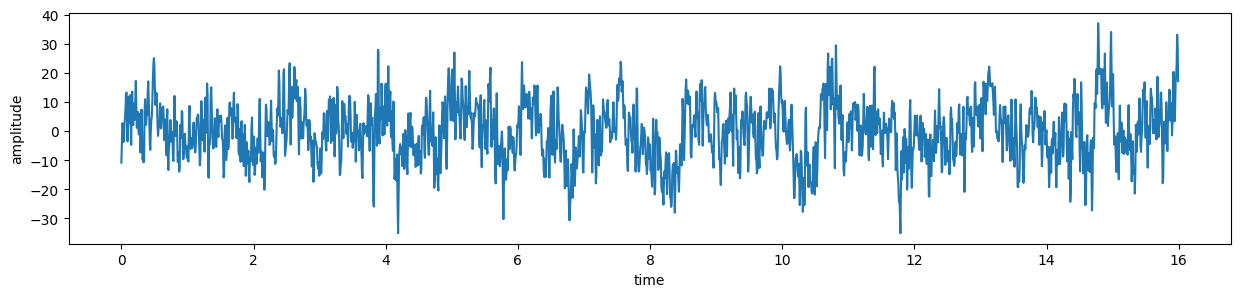

In [2]:
x,fs = spkit.load_data.eegSample_1ch()
t = np.arange(len(x))/fs

print('shape ',x.shape, t.shape)

plt.figure(figsize=(15,3))
plt.plot(t,x)
plt.xlabel('time')
plt.ylabel('amplitude')
plt.show()

## Predefined example script

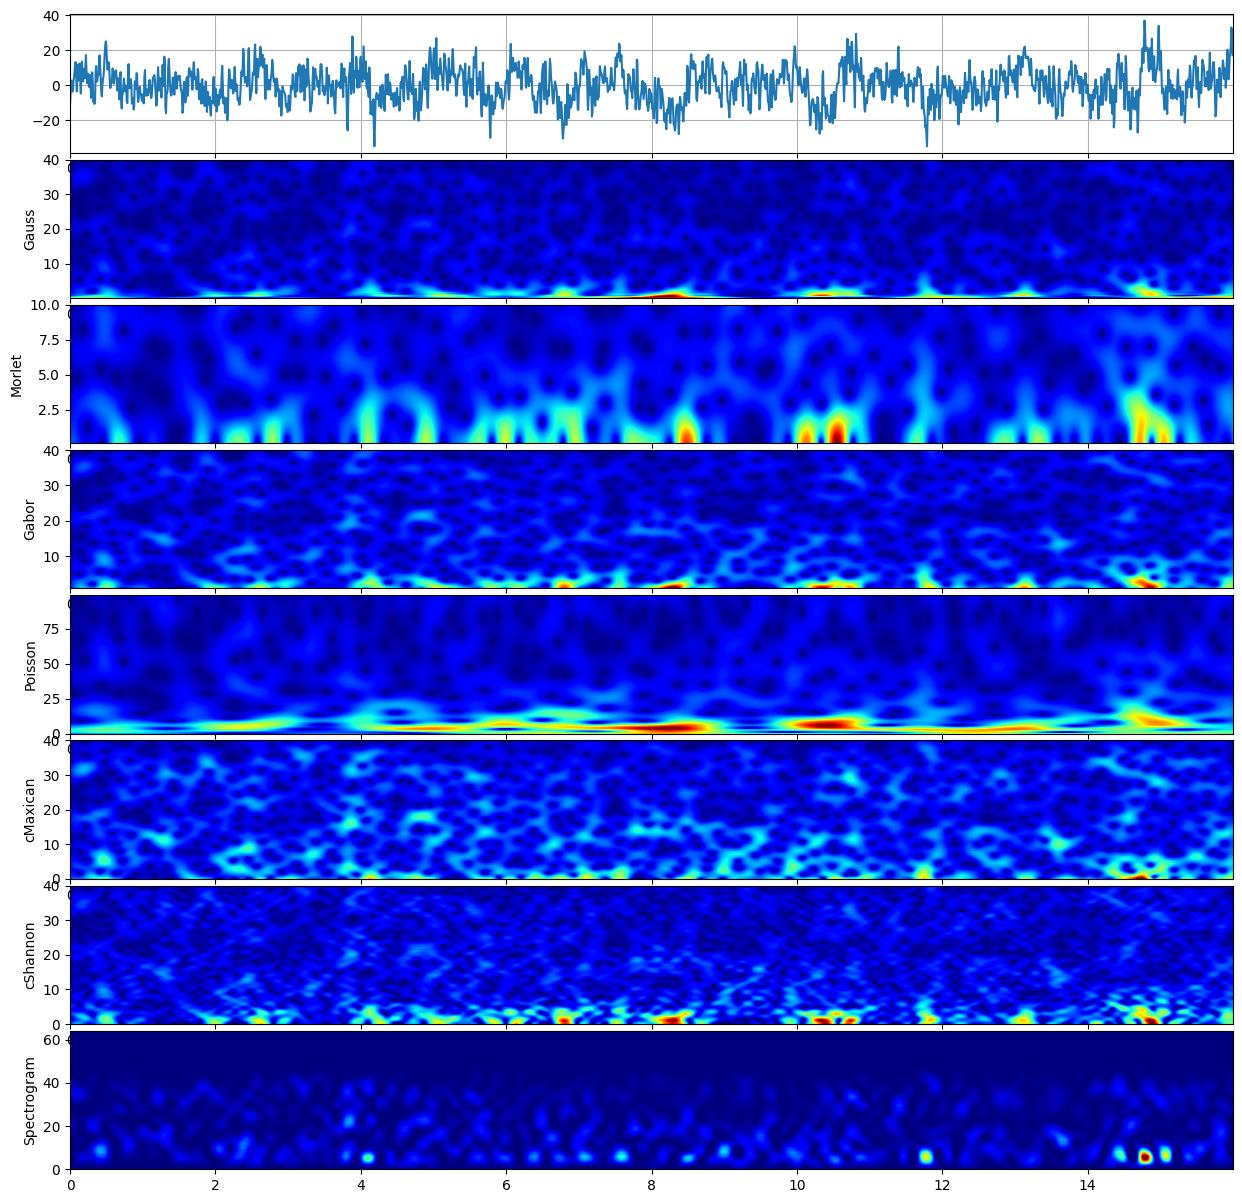

In [3]:
compare_cwt_example(x,t,fs=fs)

## Gauss wavelet

### Default parameter setting

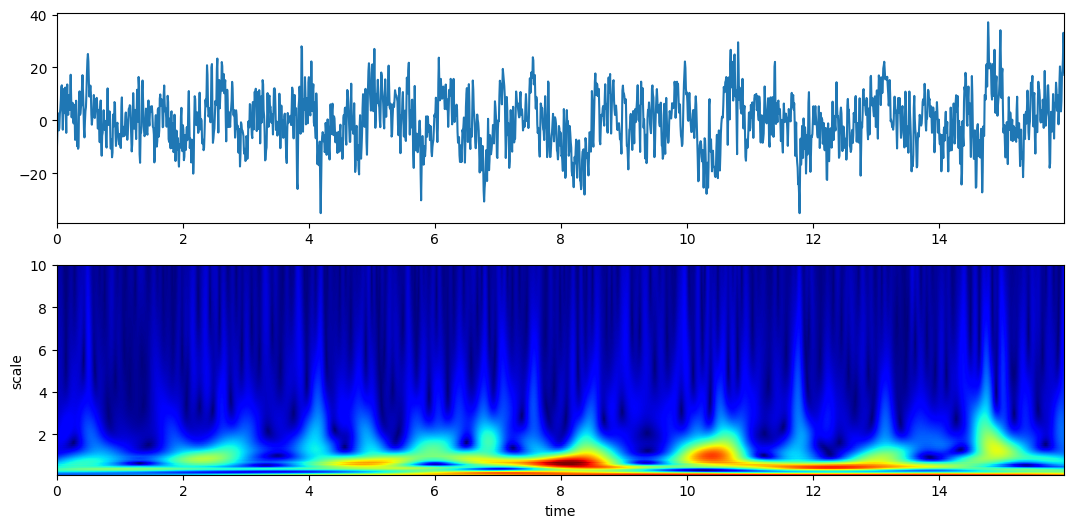

In [4]:
XW,S = ScalogramCWT(x,t,fs=fs,wType='Gauss',PlotPSD=True)

In [5]:
XW.shape, S.shape

((100, 2048), (100,))

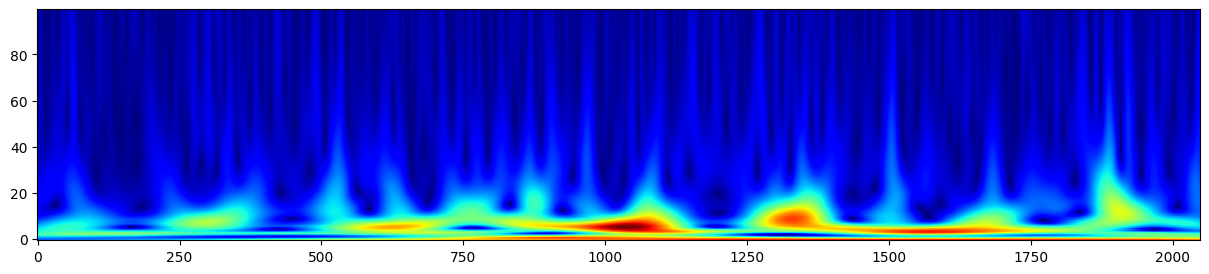

In [6]:
plt.figure(figsize=(15,3))
plt.imshow(np.abs(XW),aspect='auto',origin='lower',cmap='jet',interpolation='sinc')
plt.show()

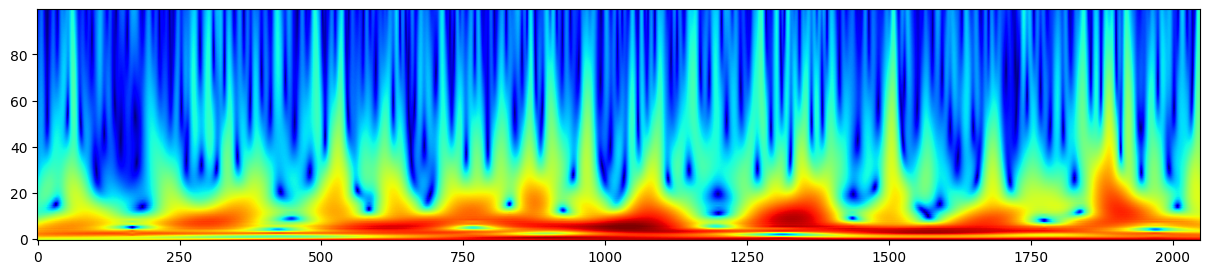

In [7]:
plt.figure(figsize=(15,3))
plt.imshow(np.log10(np.abs(XW)+0.2),aspect='auto',origin='lower',cmap='jet',interpolation='sinc')
plt.show()

### with custom setting

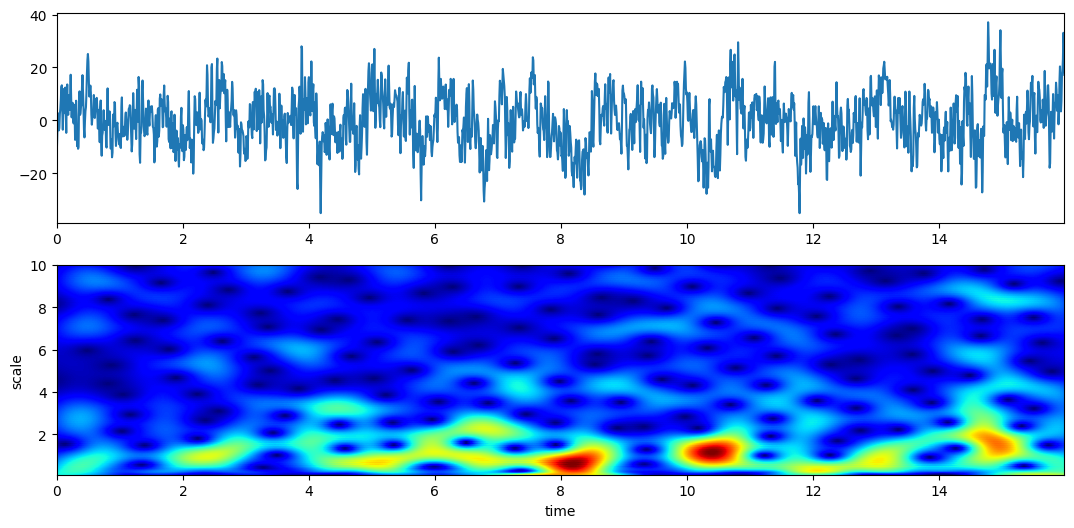

In [8]:
f0 = np.linspace(0.1,10,100)
Q  = np.linspace(0.1,5,100)
XW,S = ScalogramCWT(x,t,fs=fs,wType='Gauss',PlotPSD=True,f0=f0,Q=Q)

## Show wavelets in tim eand frequency domain

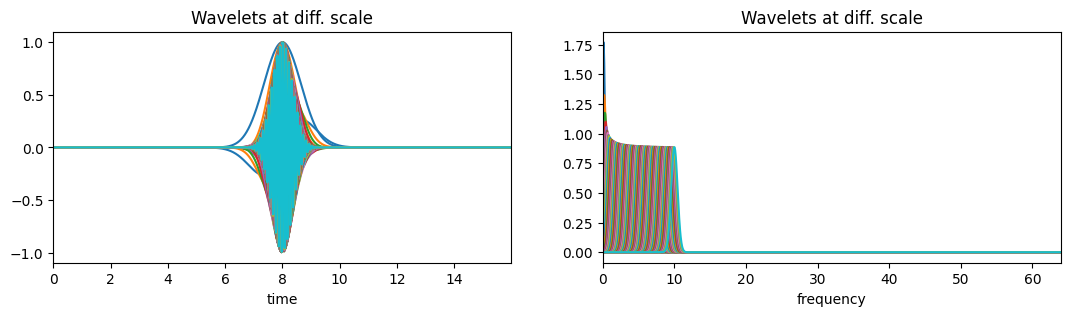

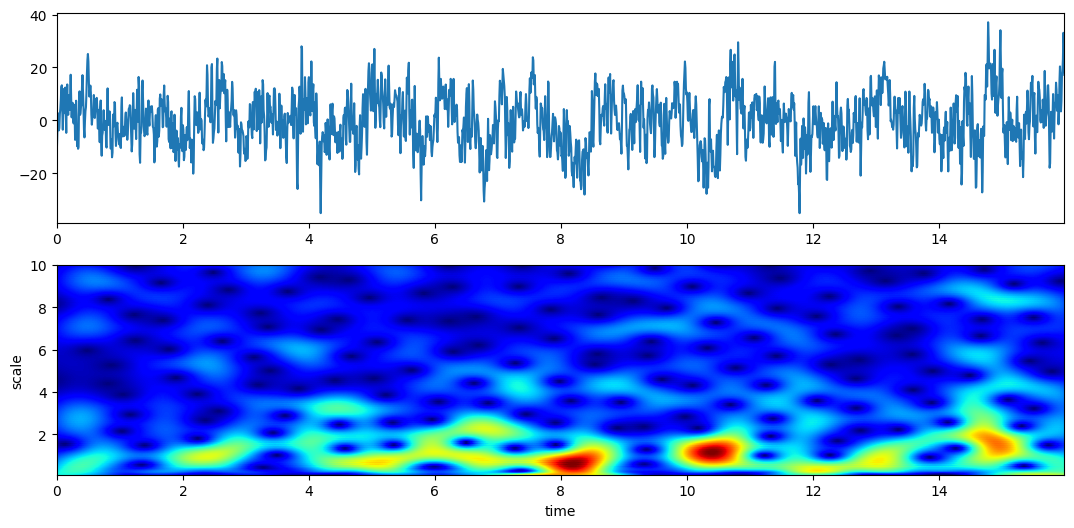

In [9]:
f0 = np.linspace(0.1,10,100)
Q  = np.linspace(0.1,5,100)
XW,S = ScalogramCWT(x,t,fs=fs,wType='Gauss',PlotPSD=True,PlotW=True,f0=f0,Q=Q)

## Other wavelets

Morlet wavelet


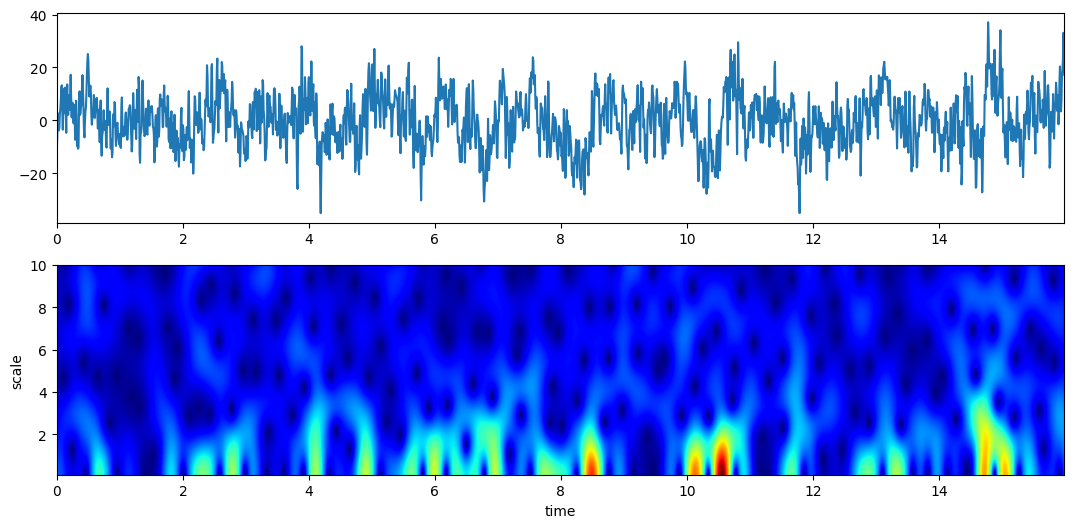

Gabor wavelet


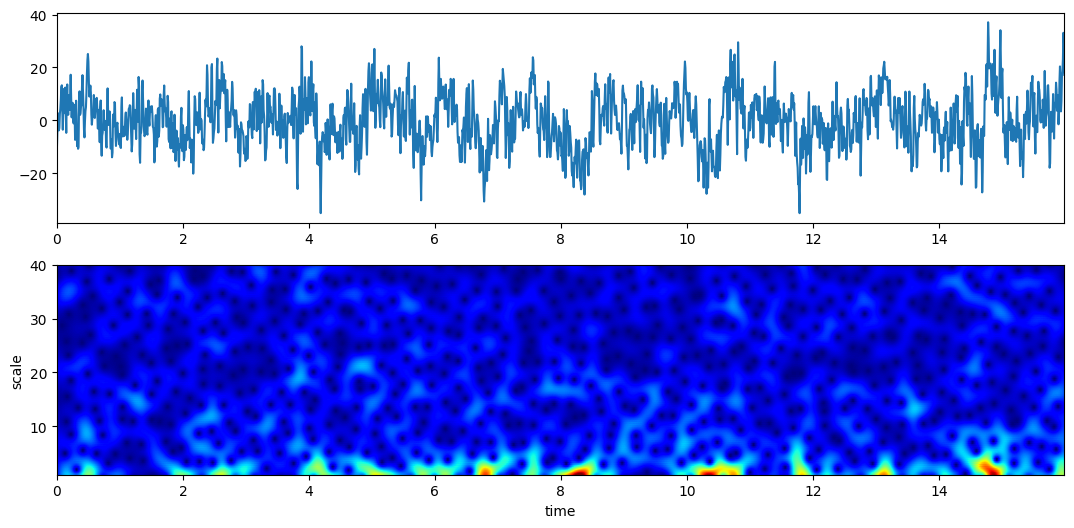

Poisson wavelet


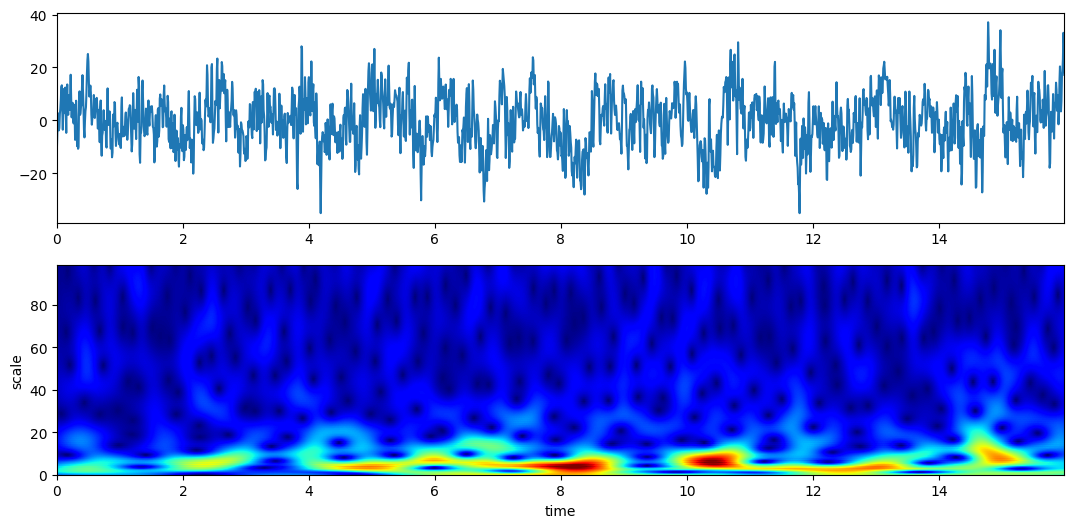

Complex Maxican wavelet


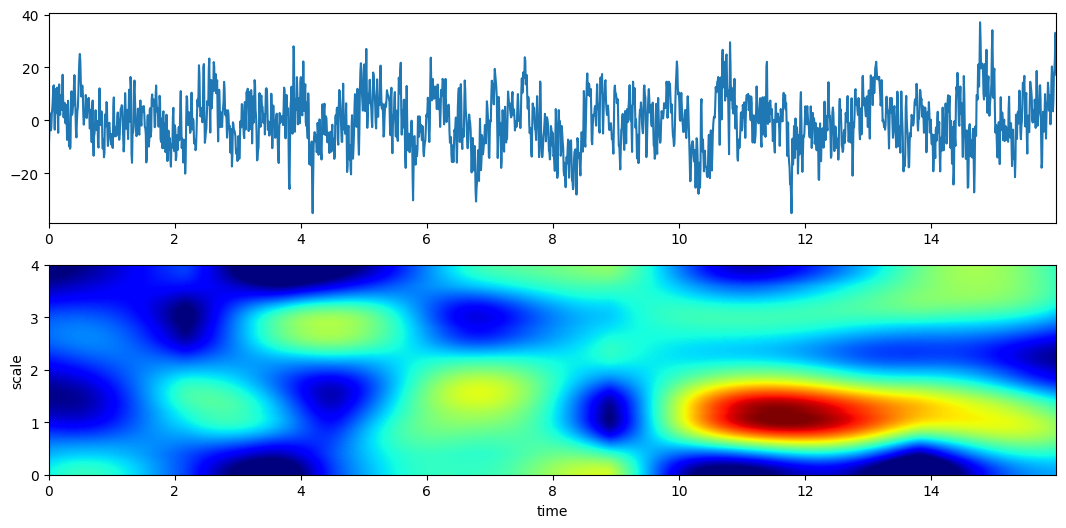

Complex Shannon wavelet


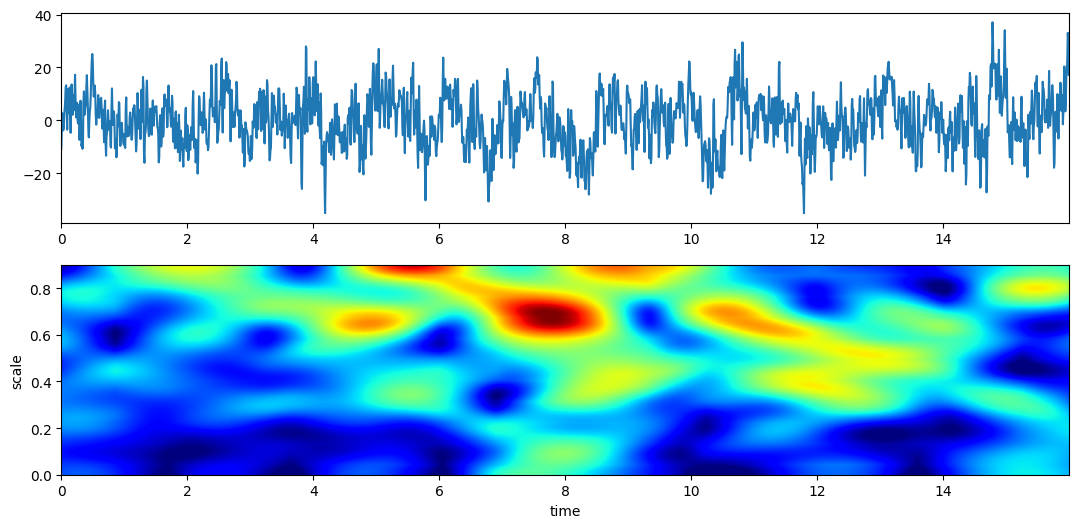

In [10]:
print('Morlet wavelet')
XW,S = ScalogramCWT(x,t,fs=fs,wType='Morlet',PlotPSD=True,)

print('Gabor wavelet')
XW,S = ScalogramCWT(x,t,fs=fs,wType='Gabor',PlotPSD=True,)

print('Poisson wavelet')
XW,S = ScalogramCWT(x,t,fs=fs,wType='Poisson',PlotPSD=True,)

print('Complex Maxican wavelet')
XW,S = ScalogramCWT(x,t,fs=fs,wType='cMaxican',PlotPSD=True,)

print('Complex Shannon wavelet')
XW,S = ScalogramCWT(x,t,fs=fs,wType='cShannon',PlotPSD=True,)

## Documentation

In [11]:
help(ScalogramCWT)

Help on function ScalogramCWT in module spkit.core.cwt:

ScalogramCWT(x, t, wType='Gauss', fs=128, PlotPSD=False, PlotW=False, fftMeth=True, interpolation='sinc', **Parameters)
    Compute scalogram using Continues Wavelet Transform for wavelet type (wType) and given scale range
    
    Parameters
    ----------
    
    x: array-like, input signal,
    t: array-like, time array corresponding to x, same length as x
    fs: sampling rate
    PlotPSD: bool, if True, plot Scalogram
    PlotW :  bool, if True, plot wavelets in time and frequecy with different scalling version
    fftMeth: if True, FFT method is used, else convolution method is used. FFT method is faster.
    interpolation: str, or None, interpolation while ploting Scalogram.
    
    Parameters for different wavelet functions
    --------
    Common Parameters for all the Wavelet functions
    
    f : array of frequency range to be analysed, e.g. np.linspace(-10,10,2*N-1), where N = len(x)
      : if None, frequency rang